DASC 5304 – Machine Learning Project Code

- Project Title: **Robustness Enhancement in Image Classification via Data Augmentation**
- Team Members: **Jagriti Koirala (ID: 1002340217), Pritesh Das (ID: 1002333230)**

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


**Project Overview**

In this project, we study how different data augmentation methods affect the accuracy and robustness of a deep learning image classifier. We start with a standard baseline model and then apply stronger augmentation techniques to see whether they improve generalization performance.

**Project Plan**

Phase1  – Train a baseline ResNet18 model on CIFAR-10.
Baseline uses standard augmentation (random crop and horizontal flip).

Phase 2 – Add Mixup during training and compare the results.

Phase 3 – Later, test robustness and expand to other datasets.

For this midway submission, we focused on CIFAR-10 first to build and test the full training pipeline before moving to the other datasets.

**Phase 1 – Baseline Model Implementation**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
import numpy as np

In [ ]:
# Data augmentation for training
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])


transform_test = transforms.Compose([
    transforms.ToTensor()
])

# Loading CIFAR-10
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True, num_workers=2
)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=128, shuffle=False, num_workers=2
)

print("Training samples:", len(trainset))
print("Test samples:", len(testset))

100%|██████████| 170M/170M [00:03<00:00, 48.1MB/s]


Training samples: 50000
Test samples: 10000


In [ ]:
# creating the ResNet18 model
model = models.resnet18(pretrained=False)

# changing the last layer to match 10 CIFAR-10 classes
model.fc = nn.Linear(model.fc.in_features, 10)

# sending the model to GPU
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
# defining loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# training loop for baseline model

num_epochs = 5
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

Epoch [1/5], Loss: 1.5472
Epoch [2/5], Loss: 1.1859
Epoch [3/5], Loss: 1.0286
Epoch [4/5], Loss: 0.9276
Epoch [5/5], Loss: 0.8507


In [ ]:
# evaluating baseline model on test set

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

baseline_accuracy = 100 * correct / total

print(f"Baseline Test Accuracy: {baseline_accuracy:.2f}%")

Baseline Test Accuracy: 67.38%


After five training epochs, the model reached 67.38% test accuracy on CIFAR-10. This number gives a starting point before trying Mixup to see if performance improves.

**Phase 2 – Mixup Implementation**

In [ ]:
# simple mixup function
def mixup_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam

In [ ]:
# training with mixup

model_mixup = models.resnet18(pretrained=False)
model_mixup.fc = nn.Linear(model_mixup.fc.in_features, 10)
model_mixup = model_mixup.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_mixup = optim.Adam(model_mixup.parameters(), lr=0.001)

num_epochs = 5

for epoch in range(num_epochs):
    model_mixup.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images = images.to(device)
        labels = labels.to(device)

        images, targets_a, targets_b, lam = mixup_data(images, labels)

        optimizer_mixup.zero_grad()

        outputs = model_mixup(images)
        loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)

        loss.backward()
        optimizer_mixup.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(trainloader):.4f}")

Epoch [1/5], Loss: 1.9485
Epoch [2/5], Loss: 1.7333
Epoch [3/5], Loss: 1.6558
Epoch [4/5], Loss: 1.6059
Epoch [5/5], Loss: 1.5372


In [ ]:
# evaluating mixup model on test set

model_mixup.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_mixup(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

mixup_accuracy = 100 * correct / total

print(f"Mixup Test Accuracy: {mixup_accuracy:.2f}%")

Mixup Test Accuracy: 56.54%


Mixup gave 56.54% test accuracy after five epochs. This is lower than the baseline result.

**Comparison**

Baseline: 67.38%
Mixup: 56.54%

Loading CIFAR‑100 and SVHN

Over here we basically create a generic loader function for all of three of the image datasets we use (CIFAR‑10, CIFAR‑100, and SVHN). Each function downloads the dataset, applies the required training and test transforms, and returns a pair of PyTorch DataLoaders for the training and test splits with a fixed batch size and shuffling configuration. Through this design we were able to plug different datasets into the same ResNet‑18 training and evaluation code without rewriting the loading logic every time for each dataset.

In [ ]:
#  Dataset loaders for CIFAR-100 and SVHN
import torchvision.datasets as datasets

batch_size = 128

def get_cifar10_loaders(transform_train, transform_test, batch_size=128):
    trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
    testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)
    return trainloader, testloader

def get_cifar100_loaders(transform_train, transform_test, batch_size=128):
    trainset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
    testset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)
    return trainloader, testloader

def get_svhn_loaders(transform_train, transform_test, batch_size=128):
    trainset = datasets.SVHN(root='./data', split='train', download=True, transform=transform_train)
    testset = datasets.SVHN(root='./data', split='test', download=True, transform=transform_test)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)
    return trainloader, testloader


ResNet18 model and training/evaluation loops

We have defined a base ResNet‑18 model

- The build_resnet18(num_classes) creates a ResNet‑18 with itsfinal fully connected layer resized to output num_classes and moves it to the selected device (CPU/GPU).

- train_model runs the standard mini‑batch training loop: it iterates over the training loader for a given number of epochs, runs forward passes, computes cross‑entropy loss, backpropagates, and updates parameters with Adam

- when use_mixup=True, it first applies mixup_data and calculates a weighted loss over the two mixed label sets.

- evaluate_model switches the model to eval mode, runs it on the test loader without gradients, and returns the overall classification accuracy.

In [ ]:
# ResNet18 model
def build_resnet18(num_classes):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

#  Train loop
def train_model(model, trainloader, num_epochs=5, optimizer=None, criterion=None, use_mixup=False, alpha=1.0):
    if optimizer is None:
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in trainloader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            if use_mixup:
                images, targets_a, targets_b, lam = mixup_data(images, labels, alpha=alpha)
                outputs = model(images)
                loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

    return model

# Test loop
def evaluate_model(model, testloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = 100.0 * correct / total
    return acc


Baseline + Mixup on CIFAR‑100

We train and evaluate ResNet 18 on CIFAR100 with and without Mixup. CIFAR 10 data transforms are resued over here. Loaders are built for CIFAR 100 and a baseline model for 3 epochs is trained after which we get the baseline accuracy as 26.38%. Then a second ResNet 18 is trained with Mixup enabled on the same data and prints the Mixup test accuracy, which in our case was about 26.38% for baseline and 23.10% for Mixup.

In [ ]:
# CIFAR-100: baseline and Mixup experiments

# Reusing CIFAR-10 transforms
transform_train_100 = transform_train
transform_test_100 = transform_test

cifar100_trainloader, cifar100_testloader = get_cifar100_loaders(
    transform_train_100, transform_test_100, batch_size=batch_size
)

# Baseline CIFAR-100
cifar100_baseline = build_resnet18(num_classes=100)
optimizer_100 = optim.Adam(cifar100_baseline.parameters(), lr=0.001)
cifar100_baseline = train_model(
    cifar100_baseline, cifar100_trainloader,
    num_epochs=3,
    optimizer=optimizer_100,
    criterion=nn.CrossEntropyLoss(),
    use_mixup=False
)
cifar100_baseline_acc = evaluate_model(cifar100_baseline, cifar100_testloader)
print(f"CIFAR-100 Baseline Test Accuracy: {cifar100_baseline_acc:.2f}%")

# Mixup CIFAR-100
cifar100_mixup = build_resnet18(num_classes=100)
optimizer_100_mix = optim.Adam(cifar100_mixup.parameters(), lr=0.001)
cifar100_mixup = train_model(
    cifar100_mixup, cifar100_trainloader,
    num_epochs=3,
    optimizer=optimizer_100_mix,
    criterion=nn.CrossEntropyLoss(),
    use_mixup=True,
    alpha=1.0
)
cifar100_mixup_acc = evaluate_model(cifar100_mixup, cifar100_testloader)
print(f"CIFAR-100 Mixup Test Accuracy: {cifar100_mixup_acc:.2f}%")


100%|██████████| 169M/169M [00:03<00:00, 47.6MB/s]


Epoch [1/3], Loss: 3.7459
Epoch [2/3], Loss: 3.1226
Epoch [3/3], Loss: 2.7986
CIFAR-100 Baseline Test Accuracy: 26.38%
Epoch [1/3], Loss: 4.1812
Epoch [2/3], Loss: 3.8715
Epoch [3/3], Loss: 3.7368
CIFAR-100 Mixup Test Accuracy: 23.10%


Baseline + Mixup on SVHN

We run SVHN experiments where ResNet 18 is trained for three epochs on 32 × 32 RGB digit images using the same augmentations as CIFAR 10. Firstly, we train a baseline model without Mixup and reports its test accuracy, which in our case reached at 84.20 %. We then trained a second ResNet 18 on the same SVHN data but with Mixup regularization enabled (alpha = 1.0) and the Mixup test accuracy, dropped to 83.47 %, indicating that Mixup under these short training settings slightly hurt performance on SVHN.

In [ ]:
# SVHN: baseline and Mixup experiments

# reusing transforms
transform_train_svhn = transform_train
transform_test_svhn = transform_test

svhn_trainloader, svhn_testloader = get_svhn_loaders(
    transform_train_svhn, transform_test_svhn, batch_size=batch_size
)

# Baseline SVHN
svhn_baseline = build_resnet18(num_classes=10)
optimizer_svhn = optim.Adam(svhn_baseline.parameters(), lr=0.001)
svhn_baseline = train_model(
    svhn_baseline, svhn_trainloader,
    num_epochs=3,
    optimizer=optimizer_svhn,
    criterion=nn.CrossEntropyLoss(),
    use_mixup=False
)
svhn_baseline_acc = evaluate_model(svhn_baseline, svhn_testloader)
print(f"SVHN Baseline Test Accuracy: {svhn_baseline_acc:.2f}%")

# Mixup SVHN
svhn_mixup = build_resnet18(num_classes=10)
optimizer_svhn_mix = optim.Adam(svhn_mixup.parameters(), lr=0.001)
svhn_mixup = train_model(
    svhn_mixup, svhn_trainloader,
    num_epochs=3,
    optimizer=optimizer_svhn_mix,
    criterion=nn.CrossEntropyLoss(),
    use_mixup=True,
    alpha=1.0
)
svhn_mixup_acc = evaluate_model(svhn_mixup, svhn_testloader)
print(f"SVHN Mixup Test Accuracy: {svhn_mixup_acc:.2f}%")


100%|██████████| 182M/182M [00:02<00:00, 82.6MB/s]
100%|██████████| 64.3M/64.3M [00:01<00:00, 47.0MB/s]


Epoch [1/3], Loss: 1.3221
Epoch [2/3], Loss: 0.6437
Epoch [3/3], Loss: 0.5151
SVHN Baseline Test Accuracy: 84.20%
Epoch [1/3], Loss: 1.9257
Epoch [2/3], Loss: 1.5003
Epoch [3/3], Loss: 1.4319
SVHN Mixup Test Accuracy: 83.47%


CIFAR‑10‑C robustness evaluation (baseline + Mixup)

We ran the trained CIFAR 10 baseline and Mixup ResNet 18 models on the CIFAR 10 C corrupted dataset. We then evaluated both models on three severity 3 corruptions (Gaussian noise, shot noise, and defocus blur). In our case, the baseline model achieved roughly 64 to 67% accuracy across these corruptions, while the Mixup model was consistently lower (around 52 to 58%) which indicates that under the current training setup, Mixup did not significantly improve the robustness.

In [ ]:
# CIFAR-10-C robustness evaluation for baseline and Mixup
import os
import tarfile
from torchvision.datasets.folder import default_loader

# Downloading CIFAR-10-C
cifar10_c_url = "https://zenodo.org/record/2535967/files/CIFAR-10-C.tar"
cifar10_c_tar = "./data/CIFAR-10-C.tar"
cifar10_c_root = "./data/CIFAR-10-C"

if not os.path.exists(cifar10_c_root):
    if not os.path.exists(cifar10_c_tar):
        !wget -O {cifar10_c_tar} {cifar10_c_url}
    with tarfile.open(cifar10_c_tar, "r") as tar:
        tar.extractall(path="./data")

# creating a loader for a single corruption type and severity
import numpy as np

def get_cifar10c_loader(corruption_name, severity=1, batch_size=128):
    data = np.load(os.path.join(cifar10_c_root, f"{corruption_name}.npy"))
    labels = np.load(os.path.join(cifar10_c_root, "labels.npy"))

    start = (severity - 1) * 10000
    end = severity * 10000
    data = data[start:end]
    labels = labels[start:end]

    data = torch.from_numpy(data).permute(0, 3, 1, 2).float() / 255.0
    labels = torch.from_numpy(labels).long()

    dataset = torch.utils.data.TensorDataset(data, labels)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    return loader

def eval_on_cifar10c(model, corruption_name, severity=1):
    loader = get_cifar10c_loader(corruption_name, severity)
    return evaluate_model(model, loader)

# EvaluatION on a few corruptions at severity 3
corruptions = ["gaussian_noise", "shot_noise", "defocus_blur"]

print("=== CIFAR-10-C robustness: Baseline model ===")
for corr in corruptions:
    acc = eval_on_cifar10c(model, corr, severity=3)  # model = CIFAR-10 baseline
    print(f"{corr}, severity 3: {acc:.2f}%")

print("\n=== CIFAR-10-C robustness: Mixup model ===")
for corr in corruptions:
    acc = eval_on_cifar10c(model_mixup, corr, severity=3)  # 'model_mixup' is your Mixup model
    print(f"{corr}, severity 3: {acc:.2f}%")

--2026-04-19 03:50:14--  https://zenodo.org/record/2535967/files/CIFAR-10-C.tar
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 137.138.153.219, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/2535967/files/CIFAR-10-C.tar [following]
--2026-04-19 03:50:15--  https://zenodo.org/records/2535967/files/CIFAR-10-C.tar
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 2918471680 (2.7G) [application/octet-stream]
Saving to: ‘./data/CIFAR-10-C.tar’

./data/CIFAR-10-C.t 100%[===================>]   2.72G  10.5MB/s    in 3m 46s  

2026-04-19 03:54:01 (12.3 MB/s) - ‘./data/CIFAR-10-C.tar’ saved [2918471680/2918471680]



/tmp/ipykernel_679/1161304867.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="./data")


=== CIFAR-10-C robustness: Baseline model ===
gaussian_noise, severity 3: 53.26%
shot_noise, severity 3: 56.92%
defocus_blur, severity 3: 61.97%

=== CIFAR-10-C robustness: Mixup model ===
gaussian_noise, severity 3: 54.95%
shot_noise, severity 3: 57.17%
defocus_blur, severity 3: 45.54%


Basic GAN skeleton for CIFAR 10

In the end we implemented a lightweight DCGAN style model to synthesize CIFAR 10 like images. The generator upsamples 100 dimensional noise through transposed convolutions and Tanh output, while the discriminator uses strided convolutions to score real versus fake images. We trained both networks jointly for 50 epochs using Adam and a standard GAN loss (BCEWithLogitsLoss) on the CIFAR‑10 training set. After training, we sampled 16 latent vectors, passed them through the generator, and plotted the resulting 32×32 RGB images in a 4×4 grid, which show blurry but class‑like shapes and colors resembling CIFAR‑10 examples.

In [ ]:
# DCGAN like generator and discriminator for CIFAR-10
import torch.nn.functional as F

nz = 100
ngf = 64
ndf = 64
nc = 3

class Generator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*4, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1)


GAN Epoch [1/50] - D loss: 0.2998, G loss: 2.8004
GAN Epoch [2/50] - D loss: 0.2017, G loss: 4.7498
GAN Epoch [3/50] - D loss: 0.3056, G loss: 2.9877
GAN Epoch [4/50] - D loss: 0.2441, G loss: 3.9840
GAN Epoch [5/50] - D loss: 1.8069, G loss: 8.2419
GAN Epoch [6/50] - D loss: 0.2431, G loss: 4.0702
GAN Epoch [7/50] - D loss: 0.0933, G loss: 3.6899
GAN Epoch [8/50] - D loss: 0.2922, G loss: 4.6334
GAN Epoch [9/50] - D loss: 0.1005, G loss: 3.5636
GAN Epoch [10/50] - D loss: 0.1012, G loss: 3.9768
GAN Epoch [11/50] - D loss: 0.0838, G loss: 3.7909
GAN Epoch [12/50] - D loss: 0.3993, G loss: 4.6611
GAN Epoch [13/50] - D loss: 0.0735, G loss: 3.9828
GAN Epoch [14/50] - D loss: 0.3025, G loss: 3.0151
GAN Epoch [15/50] - D loss: 0.0910, G loss: 3.6825
GAN Epoch [16/50] - D loss: 0.0781, G loss: 4.4099
GAN Epoch [17/50] - D loss: 0.1100, G loss: 3.4699
GAN Epoch [18/50] - D loss: 0.0549, G loss: 4.6126
GAN Epoch [19/50] - D loss: 0.1237, G loss: 4.0199
GAN Epoch [20/50] - D loss: 0.0870, G lo

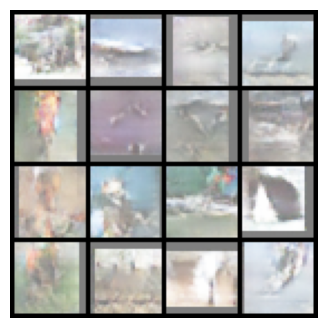

In [ ]:
# Quick GAN training loop and sample generation
from torchvision.utils import make_grid

G = Generator(nz=nz, ngf=ngf, nc=nc).to(device)
D = Discriminator(nc=nc, ndf=ndf).to(device)

criterion_gan = nn.BCEWithLogitsLoss()
optimizerD = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizerG = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))


num_gan_epochs = 50
for epoch in range(num_gan_epochs):
    for i, (imgs, _) in enumerate(trainloader):  # CIFAR-10
        imgs = imgs.to(device)

        bsz = imgs.size(0)
        real_labels = torch.ones(bsz, device=device)
        fake_labels = torch.zeros(bsz, device=device)

        # Training D on real
        optimizerD.zero_grad()
        out_real = D(imgs)
        loss_real = criterion_gan(out_real, real_labels)

        # Training D on fake
        z = torch.randn(bsz, nz, 1, 1, device=device)
        fake_imgs = G(z)
        out_fake = D(fake_imgs.detach())
        loss_fake = criterion_gan(out_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizerD.step()

        # Training G
        optimizerG.zero_grad()
        out_fake_for_G = D(fake_imgs)
        loss_G = criterion_gan(out_fake_for_G, real_labels)
        loss_G.backward()
        optimizerG.step()

    print(f"GAN Epoch [{epoch+1}/{num_gan_epochs}] - D loss: {loss_D.item():.4f}, G loss: {loss_G.item():.4f}")

# Generating a small batch of synthetic images for inspection
G.eval()
with torch.no_grad():
    z = torch.randn(16, nz, 1, 1, device=device)
    synth_imgs = G(z).cpu()  # shape [16, 3, 32, 32]

grid = make_grid(synth_imgs, nrow=4, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(4,4))
plt.axis("off")
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.show()


**Final Phase (7 April to 19 April)**

01: Final Phase Setup and Reproducibility

**Planned Number of Time Frames:**
- CIFAR-10: 20
- CIFAR-100: 15
- SVHN: 15

In [ ]:
# Set Up



import random
import copy
import time
import pandas as pd
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.utils import make_grid

# Setting random seeds for more reproducible experiments
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Making CuDNN behavior more reproducible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Final phase setup complete.")
print("Using device:", device)

# Global training settings for final phase
FINAL_BATCH_SIZE = 128
CIFAR10_EPOCHS = 20
CIFAR100_EPOCHS = 20
SVHN_EPOCHS = 15


print("Planned epochs -> CIFAR-10:", CIFAR10_EPOCHS,
      "| CIFAR-100:", CIFAR100_EPOCHS,
      "| SVHN:", SVHN_EPOCHS)

Final phase setup complete.
Using device: cuda
Planned epochs -> CIFAR-10: 20 | CIFAR-100: 20 | SVHN: 15


02: Improved Training Utilities with Mixup, Scheduler, and History Tracking

Over here we define the following:
- a cleaner ResNet-18 builder
- Mixup helper functions
- a generic training function with Mixup
- an evaluation function
- helper to summarize results neatly

In [ ]:

# IMPROVING TRAINING UTILITIES



def build_resnet18_v2(num_classes):

    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


def mixup_data_v2(x, y, alpha=1.0):

    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):    # Computing Mixup loss as weighted combination of two targets.



    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def evaluate_accuracy(model, loader):

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100.0 * correct / total


def train_model_v2(model, train_loader, test_loader, num_epochs=20,
                   lr=0.001, use_mixup=False, alpha=1.0,
                   scheduler_type="cosine"):

    # Training a model with optional Mixup and optional LR scheduling.

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    if scheduler_type == "cosine":
        scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)
    else:
        scheduler = None

    history = {
        "epoch": [],
        "train_loss": [],
        "test_acc": [],
        "lr": []
    }

    best_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            if use_mixup:
                images, targets_a, targets_b, lam = mixup_data_v2(images, labels, alpha=alpha)
                outputs = model(images)
                loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()


        if scheduler is not None:                                              # Stepping the learning rate scheduler once per epoch
            scheduler.step()

        epoch_loss = running_loss / len(train_loader)
        test_acc = evaluate_accuracy(model, test_loader)
        current_lr = optimizer.param_groups[0]["lr"]

        history["epoch"].append(epoch + 1)
        history["train_loss"].append(epoch_loss)
        history["test_acc"].append(test_acc)
        history["lr"].append(current_lr)

        if test_acc > best_acc:
            best_acc = test_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Loss: {epoch_loss:.4f} | "
              f"Test Acc: {test_acc:.2f}% | "
              f"LR: {current_lr:.6f}")


    model.load_state_dict(best_weights)                                           # Restoring best model weights

    total_time = time.time() - start_time
    print(f"\nTraining complete. Best test accuracy: {best_acc:.2f}%")
    print(f"Total training time: {total_time/60:.2f} minutes")

    return model, history


def history_to_dataframe(history, model_name, dataset_name):     # Converting training history dictionary to a DataFrame for easier inspection and final paper tables.



    df = pd.DataFrame(history)
    df["model_name"] = model_name
    df["dataset"] = dataset_name
    return df

03: Reloading Standard Dataset Loaders for Final Runs

We rebuilt the dataset loaders using the same transforms already used in the project, but we also make sure batch size is consistent for the final experiments.

CIFAR-10 and CIFAR-100 provide 50,000 training images and 10,000 test images each, while SVHN adds 73,257 training images and 26,032 test images

In [ ]:

# DATA LOADERS



# CIFAR-10 transforms
transform_train_cifar = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

transform_test_cifar = transforms.Compose([
    transforms.ToTensor()
])


transform_train_svhn_final = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

transform_test_svhn_final = transforms.Compose([
    transforms.ToTensor()
])

# Transforming for labels to ensure that they are tensors only
target_transform_cifar = transforms.Lambda(lambda y: torch.tensor(y, dtype=torch.long))

# Rebuilding CIFAR 10 loaders
cifar10_trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True,
    transform=transform_train_cifar,
    target_transform=target_transform_cifar
)
cifar10_testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True,
    transform=transform_test_cifar,
    target_transform=target_transform_cifar
)

cifar10_trainloader = torch.utils.data.DataLoader(
    cifar10_trainset, batch_size=FINAL_BATCH_SIZE, shuffle=True, num_workers=2
)
cifar10_testloader = torch.utils.data.DataLoader(
    cifar10_testset, batch_size=FINAL_BATCH_SIZE, shuffle=False, num_workers=2
)

# Rebuilding CIFAR 100 loaders
cifar100_trainset = torchvision.datasets.CIFAR100(
    root="./data", train=True, download=True,
    transform=transform_train_cifar,
    target_transform=target_transform_cifar
)
cifar100_testset = torchvision.datasets.CIFAR100(
    root="./data", train=False, download=True,
    transform=transform_test_cifar,
    target_transform=target_transform_cifar
)

cifar100_trainloader = torch.utils.data.DataLoader(
    cifar100_trainset, batch_size=FINAL_BATCH_SIZE, shuffle=True, num_workers=2
)
cifar100_testloader = torch.utils.data.DataLoader(
    cifar100_testset, batch_size=FINAL_BATCH_SIZE, shuffle=False, num_workers=2
)

# Rebuilding SVHN loaders
svhn_trainset = torchvision.datasets.SVHN(
    root="./data", split="train", download=True, transform=transform_train_svhn_final
)
svhn_testset = torchvision.datasets.SVHN(
    root="./data", split="test", download=True, transform=transform_test_svhn_final
)

svhn_trainloader = torch.utils.data.DataLoader(
    svhn_trainset, batch_size=FINAL_BATCH_SIZE, shuffle=True, num_workers=2
)
svhn_testloader = torch.utils.data.DataLoader(
    svhn_testset, batch_size=FINAL_BATCH_SIZE, shuffle=False, num_workers=2
)

print("Final phase data loaders ready.")
print("CIFAR-10 train/test:", len(cifar10_trainset), len(cifar10_testset))
print("CIFAR-100 train/test:", len(cifar100_trainset), len(cifar100_testset))
print("SVHN train/test:", len(svhn_trainset), len(svhn_testset))

Final phase data loaders ready.
CIFAR-10 train/test: 50000 10000
CIFAR-100 train/test: 50000 10000
SVHN train/test: 73257 26032


04: Tune Mixup Alpha on CIFAR‑10

We tune alpha on CIFAR-10, pick the best one, and then use that alpha in later runs if needed any further. The alpha value we chose was 0.2 as it gave us the best accuracy result at 82.68%.

In [ ]:
# MIXUP ALPHA TUNING ON CIFAR-10


alpha_candidates = [0.2, 0.4, 1.0]
alpha_results = []

for alpha_val in alpha_candidates:
    print("\n" + "="*60)
    print(f"Training CIFAR-10 Mixup model with alpha = {alpha_val}")
    print("="*60)

    model_mixup_alpha = build_resnet18_v2(num_classes=10)

    model_mixup_alpha, hist_mixup_alpha = train_model_v2(
        model=model_mixup_alpha,
        train_loader=cifar10_trainloader,
        test_loader=cifar10_testloader,
        num_epochs=CIFAR10_EPOCHS,
        lr=0.001,
        use_mixup=True,
        alpha=alpha_val,
        scheduler_type="cosine"
    )

    best_acc = max(hist_mixup_alpha["test_acc"])

    alpha_results.append({
        "alpha": alpha_val,
        "best_test_accuracy": best_acc
    })

alpha_results_df = pd.DataFrame(alpha_results).sort_values(
    by="best_test_accuracy", ascending=False
).reset_index(drop=True)

print("\nMixup alpha tuning results:")
print(alpha_results_df)

best_alpha = alpha_results_df.loc[0, "alpha"]
print(f"\nSelected best alpha for final experiments: {best_alpha}")


Training CIFAR-10 Mixup model with alpha = 0.2
Epoch [1/20] | Loss: 1.7153 | Test Acc: 50.59% | LR: 0.000994
Epoch [2/20] | Loss: 1.4515 | Test Acc: 59.29% | LR: 0.000976
Epoch [3/20] | Loss: 1.3237 | Test Acc: 62.56% | LR: 0.000946
Epoch [4/20] | Loss: 1.2531 | Test Acc: 59.48% | LR: 0.000905
Epoch [5/20] | Loss: 1.1751 | Test Acc: 61.88% | LR: 0.000854
Epoch [6/20] | Loss: 1.1532 | Test Acc: 68.44% | LR: 0.000794
Epoch [7/20] | Loss: 1.0835 | Test Acc: 72.03% | LR: 0.000727
Epoch [8/20] | Loss: 1.0200 | Test Acc: 67.68% | LR: 0.000655
Epoch [9/20] | Loss: 0.9746 | Test Acc: 73.27% | LR: 0.000578
Epoch [10/20] | Loss: 0.9438 | Test Acc: 74.35% | LR: 0.000500
Epoch [11/20] | Loss: 0.9225 | Test Acc: 64.69% | LR: 0.000422
Epoch [12/20] | Loss: 0.9117 | Test Acc: 75.88% | LR: 0.000345
Epoch [13/20] | Loss: 0.9244 | Test Acc: 79.10% | LR: 0.000273
Epoch [14/20] | Loss: 0.8069 | Test Acc: 80.07% | LR: 0.000206
Epoch [15/20] | Loss: 0.8111 | Test Acc: 80.05% | LR: 0.000146
Epoch [16/20] | 

05: Final Baseline and Mixup Experiments on CIFAR‑10, CIFAR‑100, and SVHN

Over here we train the:
- baseline model
- Mixup model (with tuned alpha from CIFAR-10 which was 0.2)
- on CIFAR-10, CIFAR-100, and SVHN. It stores final clean accuracies in a DataFrame.

Final clean accuracy results:
-     dataset            method  clean_test_accuracy (in %)
-      CIFAR-10          Baseline            82.940000
-      CIFAR-10  Mixup(alpha=0.2)            82.410000
-      CIFAR-100          Baseline            53.830000
-      CIFAR-100  Mixup(alpha=0.2)            53.340000
-      SVHN          Baseline            93.822987
-      SVHN  Mixup(alpha=0.2)            93.707744

In [ ]:

# FINAL BASELINE + MIXUP EXPERIMENTS ACROSS ALL DATASETS



final_results = []
history_frames = []

#  CIFAR-10 BASELINE
print("\nTraining FINAL CIFAR-10 baseline...")
cifar10_baseline_final = build_resnet18_v2(num_classes=10)
cifar10_baseline_final, hist_c10_base = train_model_v2(
    model=cifar10_baseline_final,
    train_loader=cifar10_trainloader,
    test_loader=cifar10_testloader,
    num_epochs=CIFAR10_EPOCHS,
    lr=0.001,
    use_mixup=False,
    scheduler_type="cosine"
)

c10_base_acc = max(hist_c10_base["test_acc"])
final_results.append({
    "dataset": "CIFAR-10",
    "method": "Baseline",
    "clean_test_accuracy": c10_base_acc
})
history_frames.append(history_to_dataframe(hist_c10_base, "Baseline", "CIFAR-10"))

#  CIFAR-10 MIXUP
print("\nTraining FINAL CIFAR-10 Mixup...")
cifar10_mixup_final = build_resnet18_v2(num_classes=10)
cifar10_mixup_final, hist_c10_mix = train_model_v2(
    model=cifar10_mixup_final,
    train_loader=cifar10_trainloader,
    test_loader=cifar10_testloader,
    num_epochs=CIFAR10_EPOCHS,
    lr=0.001,
    use_mixup=True,
    alpha=best_alpha,
    scheduler_type="cosine"
)

c10_mix_acc = max(hist_c10_mix["test_acc"])
final_results.append({
    "dataset": "CIFAR-10",
    "method": f"Mixup(alpha={best_alpha})",
    "clean_test_accuracy": c10_mix_acc
})
history_frames.append(history_to_dataframe(hist_c10_mix, f"Mixup(alpha={best_alpha})", "CIFAR-10"))

#  CIFAR-100 BASELINE
print("\nTraining FINAL CIFAR-100 baseline...")
cifar100_baseline_final = build_resnet18_v2(num_classes=100)
cifar100_baseline_final, hist_c100_base = train_model_v2(
    model=cifar100_baseline_final,
    train_loader=cifar100_trainloader,
    test_loader=cifar100_testloader,
    num_epochs=CIFAR100_EPOCHS,
    lr=0.001,
    use_mixup=False,
    scheduler_type="cosine"
)

c100_base_acc = max(hist_c100_base["test_acc"])
final_results.append({
    "dataset": "CIFAR-100",
    "method": "Baseline",
    "clean_test_accuracy": c100_base_acc
})
history_frames.append(history_to_dataframe(hist_c100_base, "Baseline", "CIFAR-100"))

#  CIFAR-100 MIXUP
print("\nTraining FINAL CIFAR-100 Mixup...")
cifar100_mixup_final = build_resnet18_v2(num_classes=100)
cifar100_mixup_final, hist_c100_mix = train_model_v2(
    model=cifar100_mixup_final,
    train_loader=cifar100_trainloader,
    test_loader=cifar100_testloader,
    num_epochs=CIFAR100_EPOCHS,
    lr=0.001,
    use_mixup=True,
    alpha=best_alpha,
    scheduler_type="cosine"
)

c100_mix_acc = max(hist_c100_mix["test_acc"])
final_results.append({
    "dataset": "CIFAR-100",
    "method": f"Mixup(alpha={best_alpha})",
    "clean_test_accuracy": c100_mix_acc
})
history_frames.append(history_to_dataframe(hist_c100_mix, f"Mixup(alpha={best_alpha})", "CIFAR-100"))

#  SVHN BASELINE
print("\nTraining FINAL SVHN baseline...")
svhn_baseline_final = build_resnet18_v2(num_classes=10)
svhn_baseline_final, hist_svhn_base = train_model_v2(
    model=svhn_baseline_final,
    train_loader=svhn_trainloader,
    test_loader=svhn_testloader,
    num_epochs=SVHN_EPOCHS,
    lr=0.001,
    use_mixup=False,
    scheduler_type="cosine"
)

svhn_base_acc = max(hist_svhn_base["test_acc"])
final_results.append({
    "dataset": "SVHN",
    "method": "Baseline",
    "clean_test_accuracy": svhn_base_acc
})
history_frames.append(history_to_dataframe(hist_svhn_base, "Baseline", "SVHN"))

#  SVHN MIXUP
print("\nTraining FINAL SVHN Mixup...")
svhn_mixup_final = build_resnet18_v2(num_classes=10)
svhn_mixup_final, hist_svhn_mix = train_model_v2(
    model=svhn_mixup_final,
    train_loader=svhn_trainloader,
    test_loader=svhn_testloader,
    num_epochs=SVHN_EPOCHS,
    lr=0.001,
    use_mixup=True,
    alpha=best_alpha,
    scheduler_type="cosine"
)

svhn_mix_acc = max(hist_svhn_mix["test_acc"])
final_results.append({
    "dataset": "SVHN",
    "method": f"Mixup(alpha={best_alpha})",
    "clean_test_accuracy": svhn_mix_acc
})
history_frames.append(history_to_dataframe(hist_svhn_mix, f"Mixup(alpha={best_alpha})", "SVHN"))

# Combining final clean accuracy results for all of them
final_results_df = pd.DataFrame(final_results)
all_histories_df = pd.concat(history_frames, ignore_index=True)

print("\nFinal clean accuracy results:")
print(final_results_df)


final_results_df.to_csv("final_clean_accuracy_results.csv", index=False)
all_histories_df.to_csv("training_histories_all_models.csv", index=False)

print("\nSaved:")
print("- final_clean_accuracy_results.csv")
print("- training_histories_all_models.csv")


Training FINAL CIFAR-10 baseline...
Epoch [1/20] | Loss: 1.5338 | Test Acc: 42.23% | LR: 0.000994
Epoch [2/20] | Loss: 1.1684 | Test Acc: 53.87% | LR: 0.000976
Epoch [3/20] | Loss: 1.0141 | Test Acc: 66.89% | LR: 0.000946
Epoch [4/20] | Loss: 0.9129 | Test Acc: 63.33% | LR: 0.000905
Epoch [5/20] | Loss: 0.8367 | Test Acc: 69.32% | LR: 0.000854
Epoch [6/20] | Loss: 0.7721 | Test Acc: 60.08% | LR: 0.000794
Epoch [7/20] | Loss: 0.7166 | Test Acc: 69.47% | LR: 0.000727
Epoch [8/20] | Loss: 0.6725 | Test Acc: 68.24% | LR: 0.000655
Epoch [9/20] | Loss: 0.6282 | Test Acc: 74.98% | LR: 0.000578
Epoch [10/20] | Loss: 0.5937 | Test Acc: 65.08% | LR: 0.000500
Epoch [11/20] | Loss: 0.5558 | Test Acc: 75.02% | LR: 0.000422
Epoch [12/20] | Loss: 0.5228 | Test Acc: 78.82% | LR: 0.000345
Epoch [13/20] | Loss: 0.4942 | Test Acc: 79.73% | LR: 0.000273
Epoch [14/20] | Loss: 0.4630 | Test Acc: 81.53% | LR: 0.000206
Epoch [15/20] | Loss: 0.4332 | Test Acc: 81.17% | LR: 0.000146
Epoch [16/20] | Loss: 0.407

06: Full CIFAR‑10‑C Evaluation Across All Corruptions and Severities

Here we evaluated the FINAL CIFAR-10 baseline and final CIFAR-10 Mixup model on all CIFAR-10-C corruptions and severity levels 1 to 5, then we computed the mean corruption accuracy, denoted as (mCA).

Mean Corruption Accuracy (mCA):
-            model          mean_corruption_accuracy (in %)
-          Baseline                         72.573158
-          Mixup(alpha=0.2)                 72.514842

In [ ]:

# FULL CIFAR-10-C ROBUSTNESS EVALUATION



import os
import tarfile


cifar10_c_url = "https://zenodo.org/record/2535967/files/CIFAR-10-C.tar"
cifar10_c_tar = "./data/CIFAR-10-C.tar"
cifar10_c_root = "./data/CIFAR-10-C"

if not os.path.exists(cifar10_c_root):
    if not os.path.exists(cifar10_c_tar):
        !wget -O {cifar10_c_tar} {cifar10_c_url}
    with tarfile.open(cifar10_c_tar, "r") as tar:
        tar.extractall(path="./data")

print("CIFAR-10-C is ready.")

# All 19 corruption types from CIFAR-10-C
all_corruptions = [
    "gaussian_noise", "shot_noise", "impulse_noise",
    "defocus_blur", "glass_blur", "motion_blur", "zoom_blur",
    "snow", "frost", "fog", "brightness",
    "contrast", "elastic_transform", "pixelate", "jpeg_compression",
    "speckle_noise", "gaussian_blur", "spatter", "saturate"
]

def get_cifar10c_loader_full(corruption_name, severity=1, batch_size=128):

   # Creating DataLoader for one corruption type at one severity level, with Each severity slice containing 10,000 images

    data = np.load(os.path.join(cifar10_c_root, f"{corruption_name}.npy"))
    labels = np.load(os.path.join(cifar10_c_root, "labels.npy"))

    start = (severity - 1) * 10000
    end = severity * 10000

    data = data[start:end]
    labels = labels[start:end]

    data = torch.from_numpy(data).permute(0, 3, 1, 2).float() / 255.0
    labels = torch.from_numpy(labels).long()

    dataset = torch.utils.data.TensorDataset(data, labels)
    loader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=False, num_workers=2
    )
    return loader


def evaluate_on_cifar10c_grid(model, model_name):

   # Evaluating a model across all corruptions and severities.

    rows = []

    for corr in all_corruptions:
        for sev in range(1, 6):
            loader = get_cifar10c_loader_full(corr, severity=sev, batch_size=FINAL_BATCH_SIZE)
            acc = evaluate_accuracy(model, loader)

            rows.append({
                "model": model_name,
                "corruption": corr,
                "severity": sev,
                "accuracy": acc
            })

            print(f"{model_name} | {corr} | severity {sev} -> {acc:.2f}%")

    return pd.DataFrame(rows)


# Evaluating both final CIFAR 10 models
c10c_baseline_df = evaluate_on_cifar10c_grid(cifar10_baseline_final, "Baseline")
c10c_mixup_df = evaluate_on_cifar10c_grid(cifar10_mixup_final, f"Mixup(alpha={best_alpha})")

c10c_all_df = pd.concat([c10c_baseline_df, c10c_mixup_df], ignore_index=True)

# Calculating mean corruption accuracy (mCA)
mca_df = (
    c10c_all_df.groupby("model")["accuracy"]
    .mean()
    .reset_index()
    .rename(columns={"accuracy": "mean_corruption_accuracy"})
)

print("\nMean Corruption Accuracy (mCA):")
print(mca_df)

# Calculating per corruption averages across all severities
per_corruption_df = (
    c10c_all_df.groupby(["model", "corruption"])["accuracy"]
    .mean()
    .reset_index()
    .rename(columns={"accuracy": "avg_accuracy_over_severities"})
)


c10c_all_df.to_csv("cifar10c_full_results.csv", index=False)
mca_df.to_csv("cifar10c_mca_summary.csv", index=False)
per_corruption_df.to_csv("cifar10c_per_corruption_summary.csv", index=False)

print("\nSaved:")
print("- cifar10c_full_results.csv")
print("- cifar10c_mca_summary.csv")
print("- cifar10c_per_corruption_summary.csv")

CIFAR-10-C is ready.
Baseline | gaussian_noise | severity 1 -> 81.60%
Baseline | gaussian_noise | severity 2 -> 78.05%
Baseline | gaussian_noise | severity 3 -> 73.13%
Baseline | gaussian_noise | severity 4 -> 70.32%
Baseline | gaussian_noise | severity 5 -> 66.58%
Baseline | shot_noise | severity 1 -> 82.32%
Baseline | shot_noise | severity 2 -> 81.19%
Baseline | shot_noise | severity 3 -> 76.54%
Baseline | shot_noise | severity 4 -> 74.25%
Baseline | shot_noise | severity 5 -> 69.05%
Baseline | impulse_noise | severity 1 -> 79.16%
Baseline | impulse_noise | severity 2 -> 73.59%
Baseline | impulse_noise | severity 3 -> 67.88%
Baseline | impulse_noise | severity 4 -> 57.19%
Baseline | impulse_noise | severity 5 -> 48.53%
Baseline | defocus_blur | severity 1 -> 82.40%
Baseline | defocus_blur | severity 2 -> 80.40%
Baseline | defocus_blur | severity 3 -> 76.55%
Baseline | defocus_blur | severity 4 -> 70.94%
Baseline | defocus_blur | severity 5 -> 56.28%
Baseline | glass_blur | severity 1

07: Plotting

- Plot 1: Clean accuracy across datasets
- Plot 2: Mean corruption accuracy (mCA)
- Plot 3: Per-corruption average accuracy

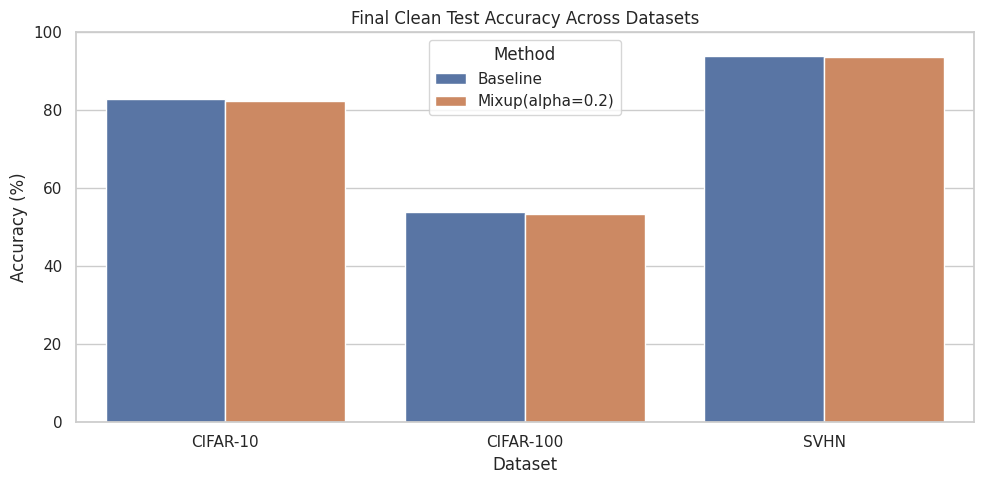

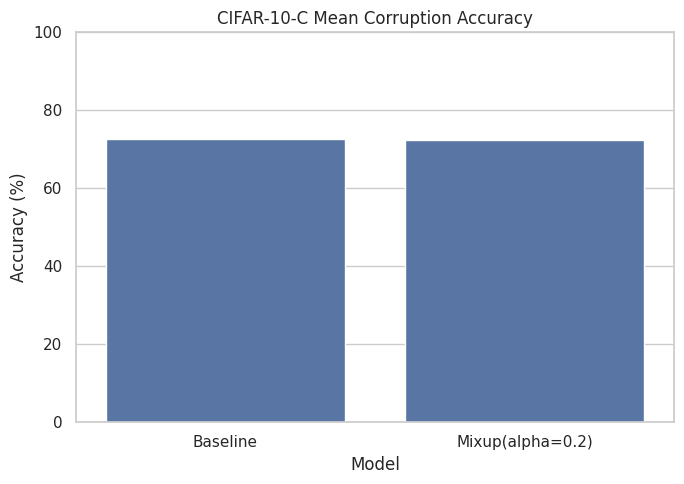

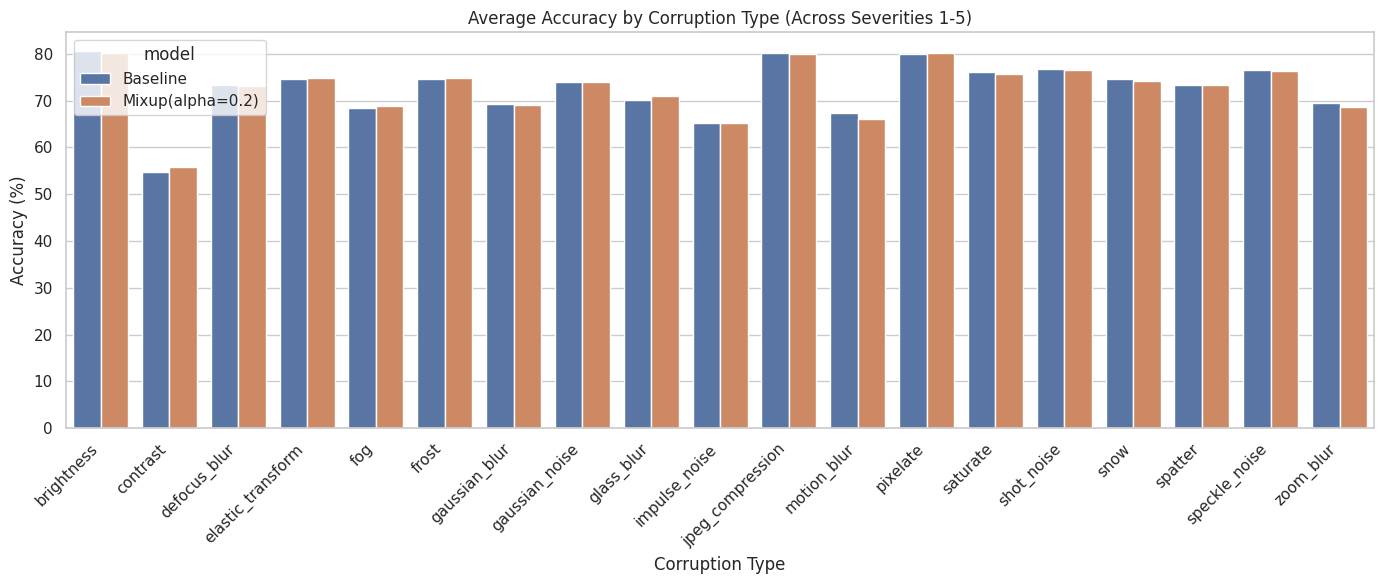

In [ ]:



import seaborn as sns

sns.set(style="whitegrid")

# Plot 1: Clean accuracy across datasets
plt.figure(figsize=(10, 5))
sns.barplot(data=final_results_df, x="dataset", y="clean_test_accuracy", hue="method")
plt.title("Final Clean Test Accuracy Across Datasets")
plt.ylabel("Accuracy (%)")
plt.xlabel("Dataset")
plt.ylim(0, 100)
plt.legend(title="Method")
plt.tight_layout()
plt.show()

# Plot 2: Mean corruption accuracy
plt.figure(figsize=(7, 5))
sns.barplot(data=mca_df, x="model", y="mean_corruption_accuracy")
plt.title("CIFAR-10-C Mean Corruption Accuracy")
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Plot 3: Per-corruption average accuracy
plt.figure(figsize=(14, 6))
sns.barplot(data=per_corruption_df, x="corruption", y="avg_accuracy_over_severities", hue="model")
plt.title("Average Accuracy by Corruption Type (Across Severities 1-5)")
plt.ylabel("Accuracy (%)")
plt.xlabel("Corruption Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

08: CutMix on CIFAR‑10

Just another Augmentation method we used for comparison. Earlier we used Mix-up, now we are using cutmix.

- Best CIFAR-10 CutMix clean test accuracy: 79.28%

In [ ]:

# CUTMIX ON CIFAR-10


def rand_bbox(size, lam):

    # Generating a random bounding box for CutMix.

    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2


def cutmix_data(x, y, alpha=1.0):

   # Applying CutMix to a mini-batch.

    lam = np.random.beta(alpha, alpha)
    rand_index = torch.randperm(x.size(0)).to(device)

    y_a = y
    y_b = y[rand_index]

    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    x[:, :, bbx1:bbx2, bby1:bby2] = x[rand_index, :, bbx1:bbx2, bby1:bby2]


    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (x.size(-1) * x.size(-2)))

    return x, y_a, y_b, lam


def train_model_cutmix(model, train_loader, test_loader, num_epochs=20, lr=0.001, alpha=1.0):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {
        "epoch": [],
        "train_loss": [],
        "test_acc": [],
        "lr": []
    }

    best_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            images, targets_a, targets_b, lam = cutmix_data(images, labels, alpha=alpha)
            outputs = model(images)
            loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()

        epoch_loss = running_loss / len(train_loader)
        test_acc = evaluate_accuracy(model, test_loader)
        current_lr = optimizer.param_groups[0]["lr"]

        history["epoch"].append(epoch + 1)
        history["train_loss"].append(epoch_loss)
        history["test_acc"].append(test_acc)
        history["lr"].append(current_lr)

        if test_acc > best_acc:
            best_acc = test_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f} | "
              f"Test Acc: {test_acc:.2f}% | LR: {current_lr:.6f}")

    model.load_state_dict(best_weights)
    print(f"\nBest CutMix test accuracy: {best_acc:.2f}%")

    return model, history


print("\nTraining optional CIFAR-10 CutMix model...")
cifar10_cutmix_final = build_resnet18_v2(num_classes=10)
cifar10_cutmix_final, hist_c10_cutmix = train_model_cutmix(
    model=cifar10_cutmix_final,
    train_loader=cifar10_trainloader,
    test_loader=cifar10_testloader,
    num_epochs=CIFAR10_EPOCHS,
    lr=0.001,
    alpha=1.0
)

cutmix_acc = max(hist_c10_cutmix["test_acc"])
print(f"CIFAR-10 CutMix clean test accuracy: {cutmix_acc:.2f}%")


Training optional CIFAR-10 CutMix model...
Epoch [1/20] | Loss: 2.0113 | Test Acc: 40.04% | LR: 0.000994
Epoch [2/20] | Loss: 1.8721 | Test Acc: 46.14% | LR: 0.000976
Epoch [3/20] | Loss: 1.7845 | Test Acc: 49.07% | LR: 0.000946
Epoch [4/20] | Loss: 1.7017 | Test Acc: 50.77% | LR: 0.000905
Epoch [5/20] | Loss: 1.6746 | Test Acc: 60.83% | LR: 0.000854
Epoch [6/20] | Loss: 1.6168 | Test Acc: 62.23% | LR: 0.000794
Epoch [7/20] | Loss: 1.5991 | Test Acc: 67.18% | LR: 0.000727
Epoch [8/20] | Loss: 1.5648 | Test Acc: 64.26% | LR: 0.000655
Epoch [9/20] | Loss: 1.5466 | Test Acc: 67.01% | LR: 0.000578
Epoch [10/20] | Loss: 1.5240 | Test Acc: 72.25% | LR: 0.000500
Epoch [11/20] | Loss: 1.5029 | Test Acc: 71.62% | LR: 0.000422
Epoch [12/20] | Loss: 1.4896 | Test Acc: 74.30% | LR: 0.000345
Epoch [13/20] | Loss: 1.4511 | Test Acc: 74.84% | LR: 0.000273
Epoch [14/20] | Loss: 1.4142 | Test Acc: 74.45% | LR: 0.000206
Epoch [15/20] | Loss: 1.4395 | Test Acc: 77.61% | LR: 0.000146
Epoch [16/20] | Loss

09: CIFAR‑10‑C (Corrupt Version of CIFAR 10) Evaluation for CutMix

CutMix mCA:
-               model                   mean_corruption_accuracy (in %)
-               CutMix(alpha=1.0)                    67.136


Updated mCA including CutMix:
-               model       mean_corruption_accuracy (in %)
-           Baseline                 72.573158
-       CutMix(alpha=1.0)            67.136000
-       Mixup(alpha=0.2)             72.514842

In [ ]:
# CIFAR-10-C EVALUATION FOR CUTMIX



c10c_cutmix_df = evaluate_on_cifar10c_grid(cifar10_cutmix_final, "CutMix(alpha=1.0)")

cutmix_mca_df = (
    c10c_cutmix_df.groupby("model")["accuracy"]
    .mean()
    .reset_index()
    .rename(columns={"accuracy": "mean_corruption_accuracy"})
)

print("\nCutMix mCA:")
print(cutmix_mca_df)


c10c_all_with_cutmix_df = pd.concat([c10c_all_df, c10c_cutmix_df], ignore_index=True)

mca_with_cutmix_df = (
    c10c_all_with_cutmix_df.groupby("model")["accuracy"]
    .mean()
    .reset_index()
    .rename(columns={"accuracy": "mean_corruption_accuracy"})
)

print("\nUpdated mCA including CutMix:")
print(mca_with_cutmix_df)

c10c_all_with_cutmix_df.to_csv("cifar10c_full_results_with_cutmix.csv", index=False)
mca_with_cutmix_df.to_csv("cifar10c_mca_summary_with_cutmix.csv", index=False)

CutMix(alpha=1.0) | gaussian_noise | severity 1 -> 77.30%
CutMix(alpha=1.0) | gaussian_noise | severity 2 -> 71.81%
CutMix(alpha=1.0) | gaussian_noise | severity 3 -> 65.11%
CutMix(alpha=1.0) | gaussian_noise | severity 4 -> 61.75%
CutMix(alpha=1.0) | gaussian_noise | severity 5 -> 57.87%
CutMix(alpha=1.0) | shot_noise | severity 1 -> 78.57%
CutMix(alpha=1.0) | shot_noise | severity 2 -> 76.93%
CutMix(alpha=1.0) | shot_noise | severity 3 -> 70.21%
CutMix(alpha=1.0) | shot_noise | severity 4 -> 66.87%
CutMix(alpha=1.0) | shot_noise | severity 5 -> 60.98%
CutMix(alpha=1.0) | impulse_noise | severity 1 -> 74.63%
CutMix(alpha=1.0) | impulse_noise | severity 2 -> 68.16%
CutMix(alpha=1.0) | impulse_noise | severity 3 -> 61.32%
CutMix(alpha=1.0) | impulse_noise | severity 4 -> 49.29%
CutMix(alpha=1.0) | impulse_noise | severity 5 -> 42.41%
CutMix(alpha=1.0) | defocus_blur | severity 1 -> 78.79%
CutMix(alpha=1.0) | defocus_blur | severity 2 -> 75.56%
CutMix(alpha=1.0) | defocus_blur | severity

10: GAN-Augmented CIFAR‑10 Training Experiment

We use the trained generator G to produce extra synthetic images, label them with a teacher model, and combine them with real CIFAR-10 training data for another augmentation experiment.



NOTE: Since the GAN is unconditional, it may not know the true class labels. We made use of pseudo-labeling through the trained CIFAR-10 baseline model to proceed accordingly.

Result
- Best CIFAR-10 GAN-augmented clean test accuracy: 82.79%

In [ ]:

# OPTIONAL: GAN-AUGMENTED CIFAR-10 CLASSIFIER EXPERIMENT


from torch.utils.data import TensorDataset, ConcatDataset

# Putting generator and teacher model into evaluation mode
G.eval()
cifar10_baseline_final.eval()

# Number of synthetic images to generate
num_synth = 5000
synth_batch_size = 250

synth_images_list = []
synth_labels_list = []

print("Generating synthetic images and pseudo-labels...")

with torch.no_grad():
    for start in range(0, num_synth, synth_batch_size):
        current_bs = min(synth_batch_size, num_synth - start)

        # Generating synthetic images from random latent vectors
        z = torch.randn(current_bs, nz, 1, 1, device=device)
        fake_imgs = G(z)

        # Re-Scaling DC GAN Output
        fake_imgs = (fake_imgs + 1) / 2.0
        fake_imgs = torch.clamp(fake_imgs, 0.0, 1.0)

        # Making use of a baseline classifier as teacher to assign pseudo-labels
        teacher_outputs = cifar10_baseline_final(fake_imgs)
        pseudo_labels = torch.argmax(teacher_outputs, dim=1)

        synth_images_list.append(fake_imgs.cpu())
        synth_labels_list.append(pseudo_labels.cpu())

synthetic_images = torch.cat(synth_images_list, dim=0)
synthetic_labels = torch.cat(synth_labels_list, dim=0)

print("Synthetic dataset shape:", synthetic_images.shape)
print("Synthetic labels shape:", synthetic_labels.shape)

# Creating a synthetic dataset
synthetic_dataset = TensorDataset(synthetic_images, synthetic_labels)

# Combining a real CIFAR-10 training set with synthetic dataset
combined_train_dataset = ConcatDataset([cifar10_trainset, synthetic_dataset])

combined_trainloader = torch.utils.data.DataLoader(
    combined_train_dataset,
    batch_size=FINAL_BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

print("Combined training dataset size:", len(combined_train_dataset))

# Training a classifier on real + GAN-generated data
print("\nTraining CIFAR-10 classifier with GAN-augmented data...")
cifar10_gan_aug_model = build_resnet18_v2(num_classes=10)

cifar10_gan_aug_model, hist_c10_gan_aug = train_model_v2(
    model=cifar10_gan_aug_model,
    train_loader=combined_trainloader,
    test_loader=cifar10_testloader,
    num_epochs=CIFAR10_EPOCHS,
    lr=0.001,
    use_mixup=False,
    scheduler_type="cosine"
)

gan_aug_acc = max(hist_c10_gan_aug["test_acc"])
print(f"\nCIFAR-10 GAN-augmented clean test accuracy: {gan_aug_acc:.2f}%")


gan_aug_result_df = pd.DataFrame([{
    "dataset": "CIFAR-10",
    "method": "Baseline + GAN synthetic data",
    "clean_test_accuracy": gan_aug_acc
}])

gan_aug_result_df.to_csv("gan_augmented_cifar10_result.csv", index=False)
print("Saved: gan_augmented_cifar10_result.csv")

Generating synthetic images and pseudo-labels...
Synthetic dataset shape: torch.Size([5000, 3, 32, 32])
Synthetic labels shape: torch.Size([5000])
Combined training dataset size: 55000

Training CIFAR-10 classifier with GAN-augmented data...
Epoch [1/20] | Loss: 1.5357 | Test Acc: 43.04% | LR: 0.000994
Epoch [2/20] | Loss: 1.1809 | Test Acc: 55.84% | LR: 0.000976
Epoch [3/20] | Loss: 1.0250 | Test Acc: 62.79% | LR: 0.000946
Epoch [4/20] | Loss: 0.9242 | Test Acc: 63.37% | LR: 0.000905
Epoch [5/20] | Loss: 0.8426 | Test Acc: 68.00% | LR: 0.000854
Epoch [6/20] | Loss: 0.7841 | Test Acc: 71.93% | LR: 0.000794
Epoch [7/20] | Loss: 0.7292 | Test Acc: 69.60% | LR: 0.000727
Epoch [8/20] | Loss: 0.6848 | Test Acc: 72.04% | LR: 0.000655
Epoch [9/20] | Loss: 0.6387 | Test Acc: 75.80% | LR: 0.000578
Epoch [10/20] | Loss: 0.6023 | Test Acc: 77.19% | LR: 0.000500
Epoch [11/20] | Loss: 0.5608 | Test Acc: 75.25% | LR: 0.000422
Epoch [12/20] | Loss: 0.5282 | Test Acc: 79.08% | LR: 0.000345
Epoch [13/2

11: CIFAR‑10‑C (Corrupt version of CIFAR 10) Evaluation for GAN-Augmented Model

This enables us to compare baseline vs Mixup vs GAN-augmented on robustness as well.

GAN-augmented model mCA:
-                          model                       mean_corruption_accuracy (in %)
-                 Baseline + GAN synthetic data                 72.646842

In [ ]:
#  CIFAR-10-C EVALUATION FOR GAN-AUGMENTED MODEL


c10c_gan_aug_df = evaluate_on_cifar10c_grid(
    cifar10_gan_aug_model,
    "Baseline + GAN synthetic data"
)

gan_aug_mca_df = (
    c10c_gan_aug_df.groupby("model")["accuracy"]
    .mean()
    .reset_index()
    .rename(columns={"accuracy": "mean_corruption_accuracy"})
)

print("\nGAN-augmented model mCA:")
print(gan_aug_mca_df)

c10c_gan_aug_df.to_csv("cifar10c_gan_aug_results.csv", index=False)
gan_aug_mca_df.to_csv("cifar10c_gan_aug_mca.csv", index=False)

Baseline + GAN synthetic data | gaussian_noise | severity 1 -> 80.93%
Baseline + GAN synthetic data | gaussian_noise | severity 2 -> 77.80%
Baseline + GAN synthetic data | gaussian_noise | severity 3 -> 73.58%
Baseline + GAN synthetic data | gaussian_noise | severity 4 -> 70.46%
Baseline + GAN synthetic data | gaussian_noise | severity 5 -> 66.78%
Baseline + GAN synthetic data | shot_noise | severity 1 -> 82.07%
Baseline + GAN synthetic data | shot_noise | severity 2 -> 80.90%
Baseline + GAN synthetic data | shot_noise | severity 3 -> 76.24%
Baseline + GAN synthetic data | shot_noise | severity 4 -> 73.79%
Baseline + GAN synthetic data | shot_noise | severity 5 -> 69.04%
Baseline + GAN synthetic data | impulse_noise | severity 1 -> 78.97%
Baseline + GAN synthetic data | impulse_noise | severity 2 -> 73.33%
Baseline + GAN synthetic data | impulse_noise | severity 3 -> 67.77%
Baseline + GAN synthetic data | impulse_noise | severity 4 -> 57.05%
Baseline + GAN synthetic data | impulse_nois

The End